In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Goa.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61392 entries, 0 to 61391
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               61392 non-null  int64  
 1   MO                 61392 non-null  int64  
 2   DY                 61392 non-null  int64  
 3   HR                 61392 non-null  int64  
 4   ALLSKY_SFC_SW_DWN  61392 non-null  float64
 5   T2M                61392 non-null  float64
 6   RH2M               61392 non-null  float64
 7   PS                 61392 non-null  float64
 8   WS10M              61392 non-null  float64
 9   ALLSKY_KT          61392 non-null  float64
 10  PRECTOTCORR        61392 non-null  float64
 11  SZA                61392 non-null  float64
dtypes: float64(8), int64(4)
memory usage: 5.6 MB


In [ ]:
# df.isnull().sum()
(df == -999).sum()

YEAR                     0
MO                       0
DY                       0
HR                       0
ALLSKY_SFC_SW_DWN        0
T2M                      0
RH2M                     0
PS                       0
WS10M                    0
ALLSKY_KT            29372
PRECTOTCORR              0
SZA                      0
dtype: int64

In [ ]:
print(df.columns)

Index(['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PS',
       'WS10M', 'ALLSKY_KT', 'PRECTOTCORR', 'SZA'],
      dtype='str')


In [ ]:
df["datetime"] = pd.to_datetime(
    df[["YEAR", "MO", "DY", "HR"]].rename(columns={
        "YEAR":"year",
        "MO":"month",
        "DY":"day",
        "HR":"hour"
    })
)
df = df.sort_values("datetime")

In [ ]:
df.replace(-999, np.nan, inplace=True)
df.dropna(inplace=True)
(df == -999).sum()

YEAR                 0
MO                   0
DY                   0
HR                   0
ALLSKY_SFC_SW_DWN    0
T2M                  0
RH2M                 0
PS                   0
WS10M                0
ALLSKY_KT            0
PRECTOTCORR          0
SZA                  0
datetime             0
dtype: int64

In [ ]:
df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month
df["dayofyear"] = df["datetime"].dt.dayofyear

In [ ]:
y = df["ALLSKY_SFC_SW_DWN"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [ ]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:07:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test,xgb_pred))

r2 = r2_score(y_test,xgb_pred)

print("MAE : ",mae)
print("RMSE : " ,rmse)
print("R2_Score : ", r2)

MAE :  9.991482310800684
RMSE :  14.364394222160824
R2_Score :  0.9973837011574109


In [ ]:
print(X.columns)
print("ALLSKY_SFC_SW_DWN" in X.columns)

print(X.columns.tolist())

Index(['ALLSKY_KT', 'T2M', 'RH2M', 'PS', 'WS10M', 'PRECTOTCORR', 'hour',
       'month', 'dayofyear'],
      dtype='str')
False
['ALLSKY_KT', 'T2M', 'RH2M', 'PS', 'WS10M', 'PRECTOTCORR', 'hour', 'month', 'dayofyear']


       Feature  Importance
0    ALLSKY_KT    0.827825
5  PRECTOTCORR    0.069095
6         hour    0.059158
1          T2M    0.011655
7        month    0.009575
8    dayofyear    0.009252
3           PS    0.006758
4        WS10M    0.006487
2         RH2M    0.000195


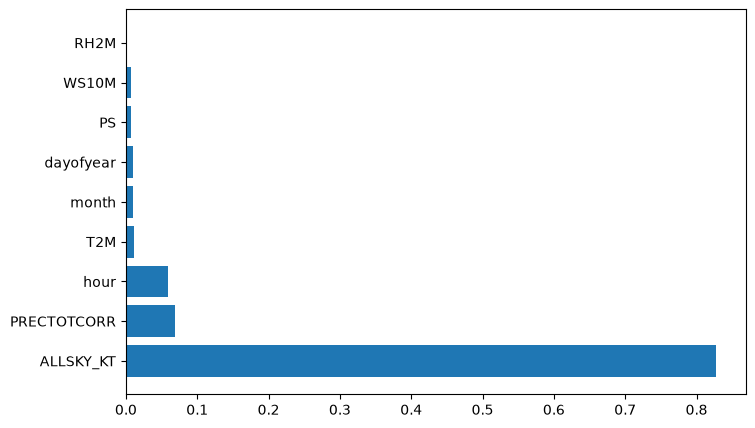

In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

target_corr = (
    corr["ALLSKY_SFC_SW_DWN"].sort_values(ascending=False)
)
print(target_corr)

ALLSKY_SFC_SW_DWN    1.000000
ALLSKY_KT            0.890131
T2M                  0.556217
PS                   0.208905
HR                   0.004458
hour                 0.004458
DY                  -0.007448
YEAR                -0.017100
MO                  -0.125994
month               -0.125994
dayofyear           -0.126010
WS10M               -0.150056
PRECTOTCORR         -0.229188
RH2M                -0.502345
SZA                 -0.836075
Name: ALLSKY_SFC_SW_DWN, dtype: float64


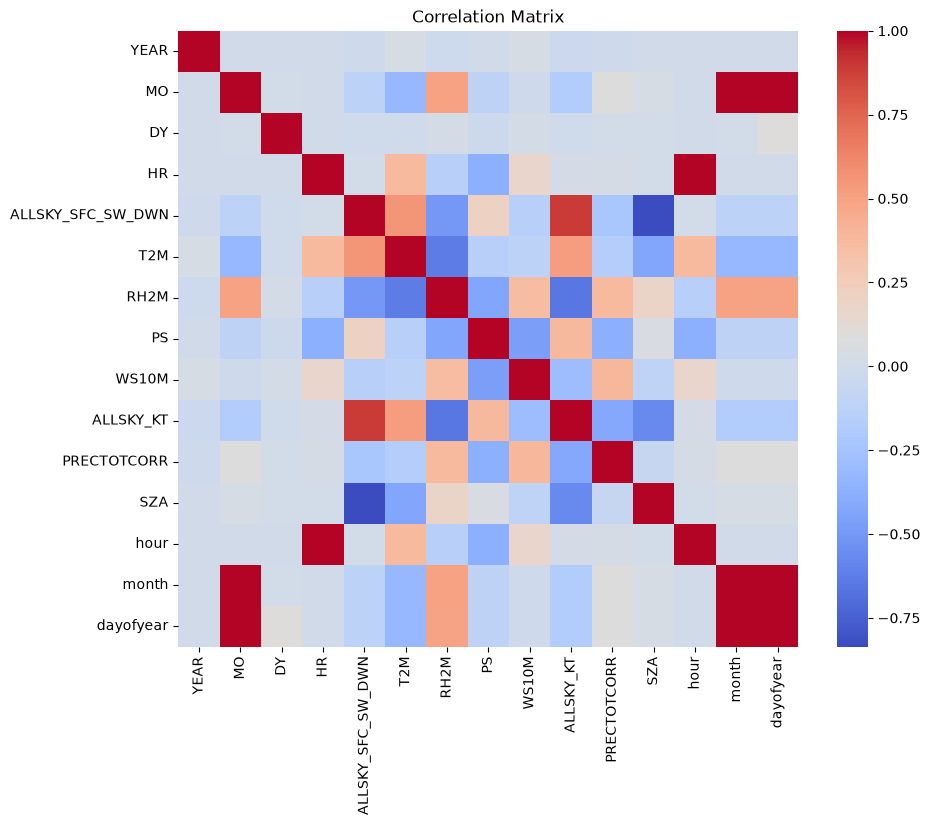

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr, 
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df["target_1h"] = df["ALLSKY_SFC_SW_DWN"].shift(-1)
df["target_6h"] = df["ALLSKY_SFC_SW_DWN"].shift(-6)
df["target_12h"] = df["ALLSKY_SFC_SW_DWN"].shift(-12)
df["target_24h"] = df["ALLSKY_SFC_SW_DWN"].shift(-24)

df.dropna(inplace=True)

In [ ]:
y = df["target_1h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [ ]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:07:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 21.6416213056609
RMSE : 33.748703269373216
R2 : 0.9855671309237048


In [ ]:
y = df["target_6h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:07:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 51.25149164308608
RMSE : 79.07443589893124
R2 : 0.9207196604761347


In [ ]:
y = df["target_12h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:07:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 57.92522135518007
RMSE : 91.01528231998779
R2 : 0.8949783746678378


In [ ]:
y = df["target_24h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:07:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 69.81371352018229
RMSE : 106.17088691155588
R2 : 0.8571340551643865


In [ ]:
results = pd.DataFrame({
    "Horizon":["1h", "6h", "12h", "24h"],
    "MAE":[21.6416213056609,51.25149164308608,57.92522135518007,69.81371352018229],
    "RMSE":[33.748703269373216,79.07443589893124,91.01528231998779,106.17088691155588],
    "R2":[0.9855671309237048,0.9207196604761347,0.8949783746678378,0.8571340551643865]
})

print(results)

  Horizon        MAE        RMSE        R2
0      1h  21.641621   33.748703  0.985567
1      6h  51.251492   79.074436  0.920720
2     12h  57.925221   91.015282  0.894978
3     24h  69.813714  106.170887  0.857134


In [ ]:
xgb.fit(X_train,y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:07:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
train_residuals = y_train.values - xgb_train_pred
test_residuals = y_test.values - xgb_test_pred

print(train_residuals[:10])

[  2.95935993 -14.05777588  17.66741333  46.9317688   37.93991699
  36.90511963  29.1930542   15.99509277 -29.3701123   30.79390259]


In [ ]:
from sklearn.preprocessing import MinMaxScaler

res_scaler = MinMaxScaler()

train_residuals_scaled = res_scaler.fit_transform(
    train_residuals.reshape(-1,1)
)

test_residuals_scaled = res_scaler.transform(
    test_residuals.reshape(-1,1)
)

In [ ]:
lookback = 24

import numpy as np

def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(len(data)-lookback):

        X.append(data[i:i+lookback])

        y.append(data[i+lookback])

    return np.array(X), np.array(y)

X_res_train, y_res_train = create_sequences(
    train_residuals_scaled,
    lookback
)

X_res_test, y_res_test = create_sequences(
    test_residuals_scaled,
    lookback
)

In [ ]:
print(X_res_train.shape)
print(y_res_train.shape)

(25572, 24, 1)
(25572, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(lookback,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_res_train,
    y_res_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0061 - val_loss: 0.0027
Epoch 2/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 3/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 4/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 5/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 6/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 7/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 8/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 9/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 10/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 11/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 12/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

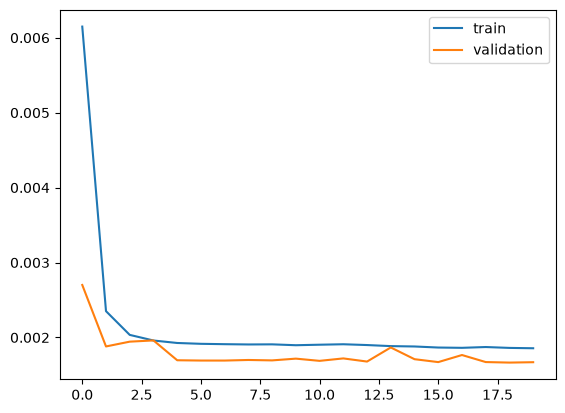

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()

In [ ]:
residual_pred_scaled = model.predict(
    X_res_test
)

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step


In [ ]:
residual_pred = res_scaler.inverse_transform(
    residual_pred_scaled
)

In [ ]:
lookback = 24
xgb_test_aligned = xgb_test_pred[lookback:]

y_test_aligned = y_test.values[lookback:]

hybrid_pred = (
    xgb_test_aligned
    +
    residual_pred.flatten()
)

Hybrid MAE : 36.77214421945429
Hybrid RMSE : 50.57285898220787
Hybrid R2 : 0.9675982292925379


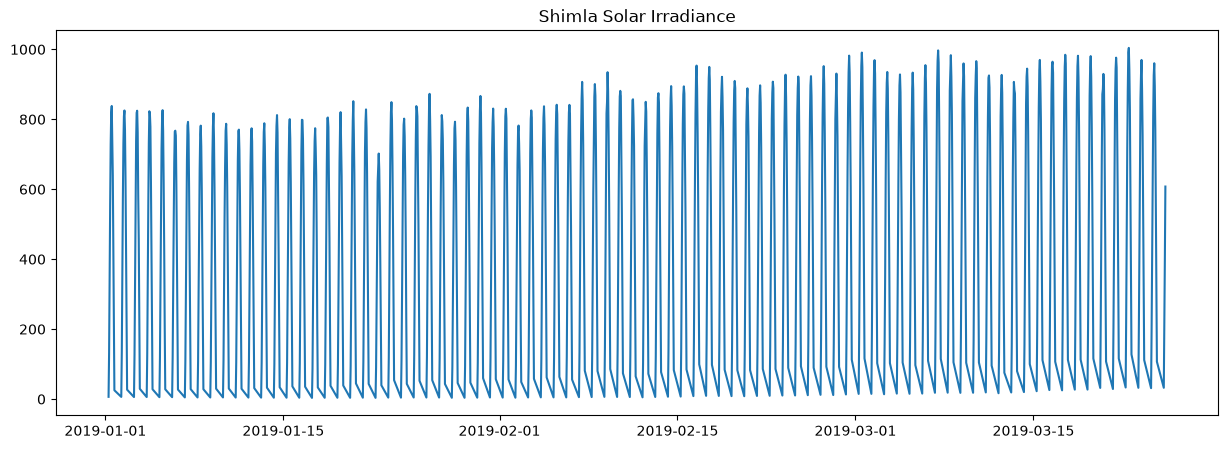

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test_aligned,
    hybrid_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_aligned,
        hybrid_pred
    )
)

r2 = r2_score(
    y_test_aligned,
    hybrid_pred
)

print("Hybrid MAE :", mae)
print("Hybrid RMSE :", rmse)
print("Hybrid R2 :", r2)


plt.figure(figsize=(15,5))

plt.plot(
    df["datetime"][:1000],
    df["ALLSKY_SFC_SW_DWN"][:1000]
)

plt.title("Shimla Solar Irradiance")
plt.show()